<a href="https://colab.research.google.com/github/lokendrasinghofficial/Predicting-Personal-Loan-Acceptance-of-Universal-Bank-Customers-using-Logistic-Regression/blob/main/Logistic_Regression_UniversalBank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universal Bank
## Logistic Regression

### Problem Statement

Build a model which predicts **Personal Loan acceptance** by Universal Bank customers.

### Data
Contains data about **5000 customers**. The goal is to predict whether a customer will accept a personal loan offer.

**Data Description**
Age: Customer’s age in completed years  
Experience: Number of years of professional experience  
Income: Annual income of the customer
Family Size: Family size of the customer  
CCAvg: Average spending on credit cards per month  
Education: Education Level. 1: Undergrad; 2: Graduate; 3: Advanced/Professional  
Mortgage: Value of house mortgage if any   
Securities Account: (1 f customer has securities account with bank, 0 otherwise)  
CD Account: (1 if customer has certificate of deposit (CD) account with bank, 0 otherwise)  
Online Banking: (1 if customer uses Internet banking facilities, 0 otherwise)  
Credit Card: (1 if customer uses credit card issued by Universal Bank, 0 otherwise)

### Import necessary libraries

In [1]:
# To filter warnings
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# To build logistic regression model for statistical analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# To get different metric scores
from sklearn.metrics import (
    accuracy_score, roc_curve, confusion_matrix,
    roc_auc_score, classification_report
)

### Read the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Big data/23 04/UniversalBank.csv")

### View the first and last 5 rows of the dataset

In [ ]:
data.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
data.tail()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Understand the shape of the dataset

In [ ]:
data.shape

(5000, 14)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 5000 non-null   int64  
 1   Age                5000 non-null   int64  
 2   Experience         5000 non-null   int64  
 3   Income             5000 non-null   int64  
 4   ZIP Code           5000 non-null   int64  
 5   Family             5000 non-null   int64  
 6   CCAvg              5000 non-null   float64
 7   Education          5000 non-null   int64  
 8   Mortgage           5000 non-null   int64  
 9   PersonalLoan       5000 non-null   int64  
 10  SecuritiesAccount  5000 non-null   int64  
 11  CDAccount          5000 non-null   int64  
 12  Online             5000 non-null   int64  
 13  CreditCard         5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
PersonalLoan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


### Drop irrelevant columns

- `ID`
- `ZIP Code`

In [ ]:
data = data.drop(['ID', 'ZIP Code'], axis=1)
print("Remaining columns:", data.columns.tolist())
print("Shape after dropping:", data.shape)

Remaining columns: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'PersonalLoan', 'SecuritiesAccount', 'CDAccount', 'Online', 'CreditCard']
Shape after dropping: (5000, 12)


### Checking for null values in the data

In [ ]:
data.isnull().sum()

,0
Age,0
Experience,0
Income,0
Family,0
CCAvg,0
Education,0
Mortgage,0
PersonalLoan,0
SecuritiesAccount,0
CDAccount,0


- There are **no missing values** in the UniversalBank dataset.

### Distribution of variables in the data

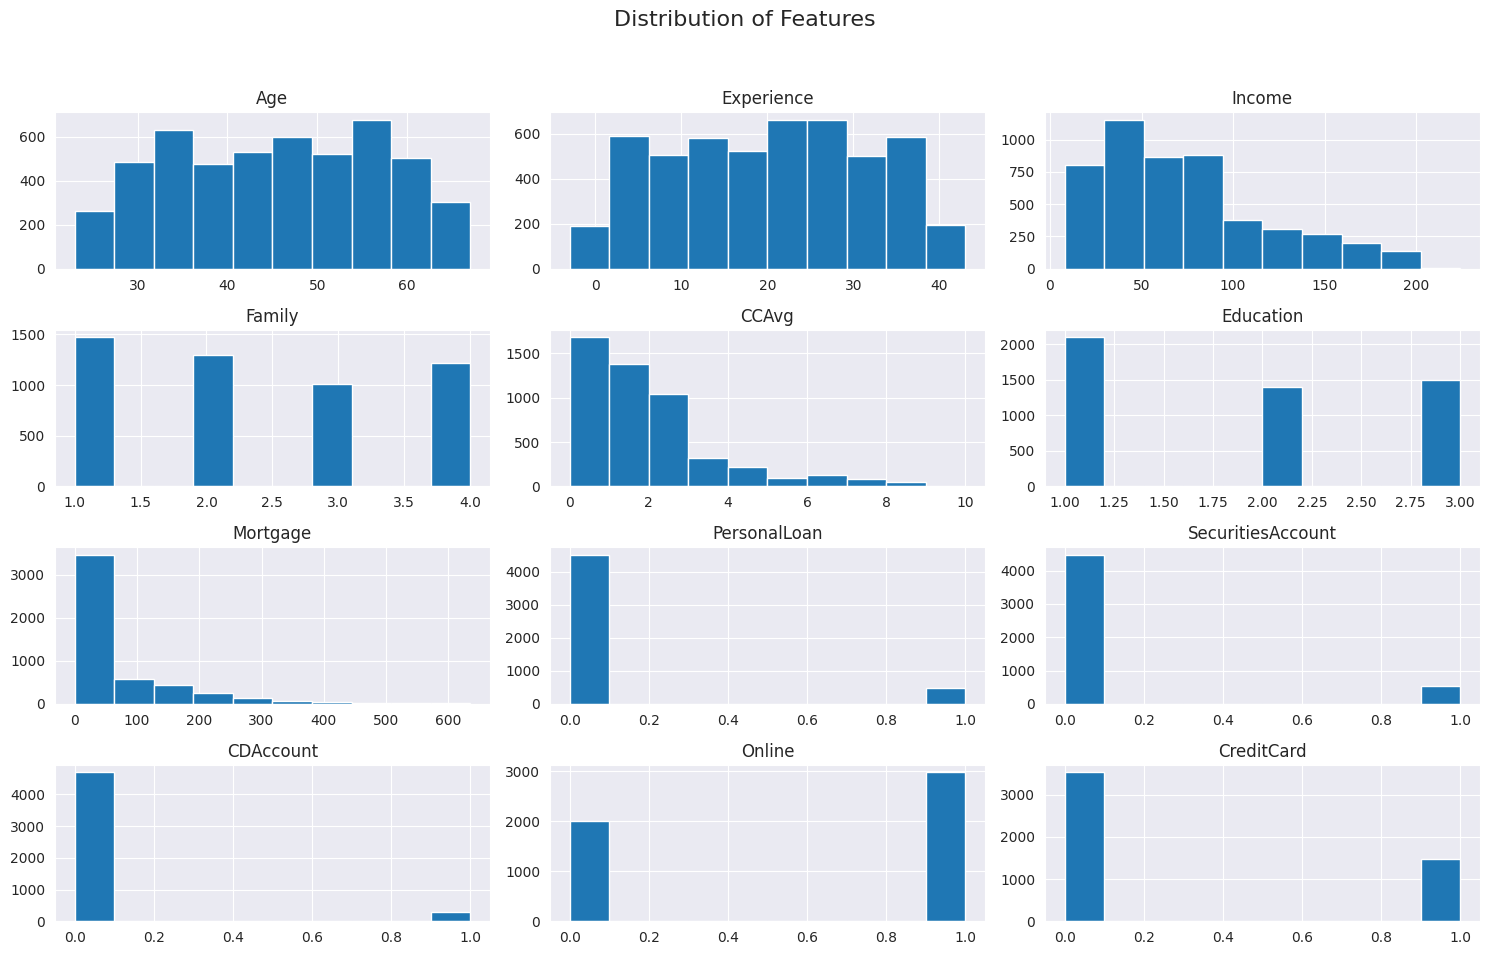

In [ ]:
sns.set_style("darkgrid")
data.hist(figsize=(15, 10))
plt.suptitle('Distribution of Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Observations:**
- `Income` and `CCAvg` are right-skewed — most customers have lower income/spending, with a long tail.
- `Mortgage` has many 0 values, meaning many customers have no mortgage — this is valid, not a data error.
- `Education`, `Family`, `SecuritiesAccount`, `CDAccount`, `Online`, `CreditCard` are categorical/discrete.
- `Age` and `Experience` are roughly normally distributed.

### Bivariate Analysis

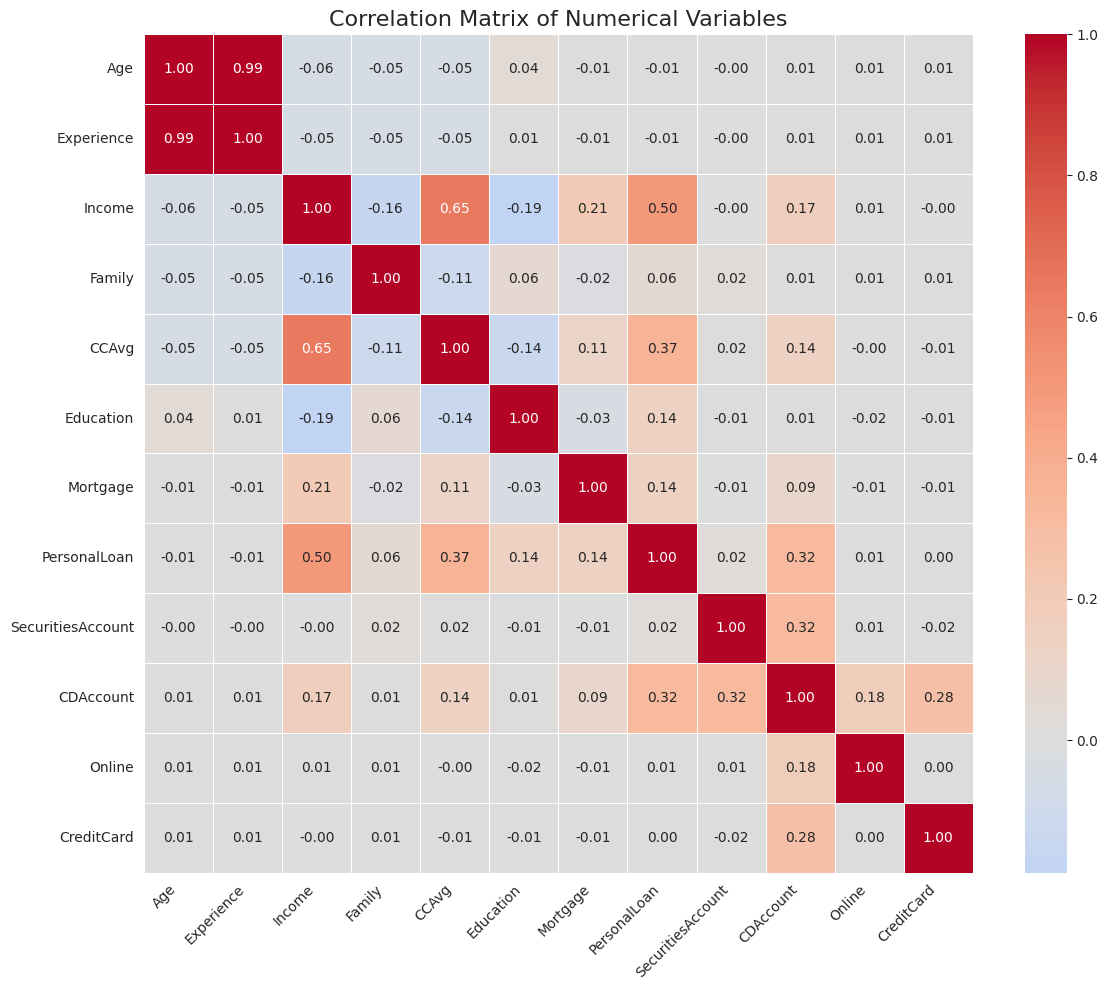

In [ ]:
# Correlation heatmap showing pairwise relationships between numerical variables
corr = data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=.7)
plt.title("Correlation Matrix of Numerical Variables", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Observations:**
- `Age` and `Experience` have very high correlation (~0.99)this will cause **multicollinearity**.
- `Income` and `CCAvg` are moderately correlated — makes sense, higher income → more spending.
- `PersonalLoan` has the highest positive correlation with `Income`, `CCAvg`, and `CDAccount`.

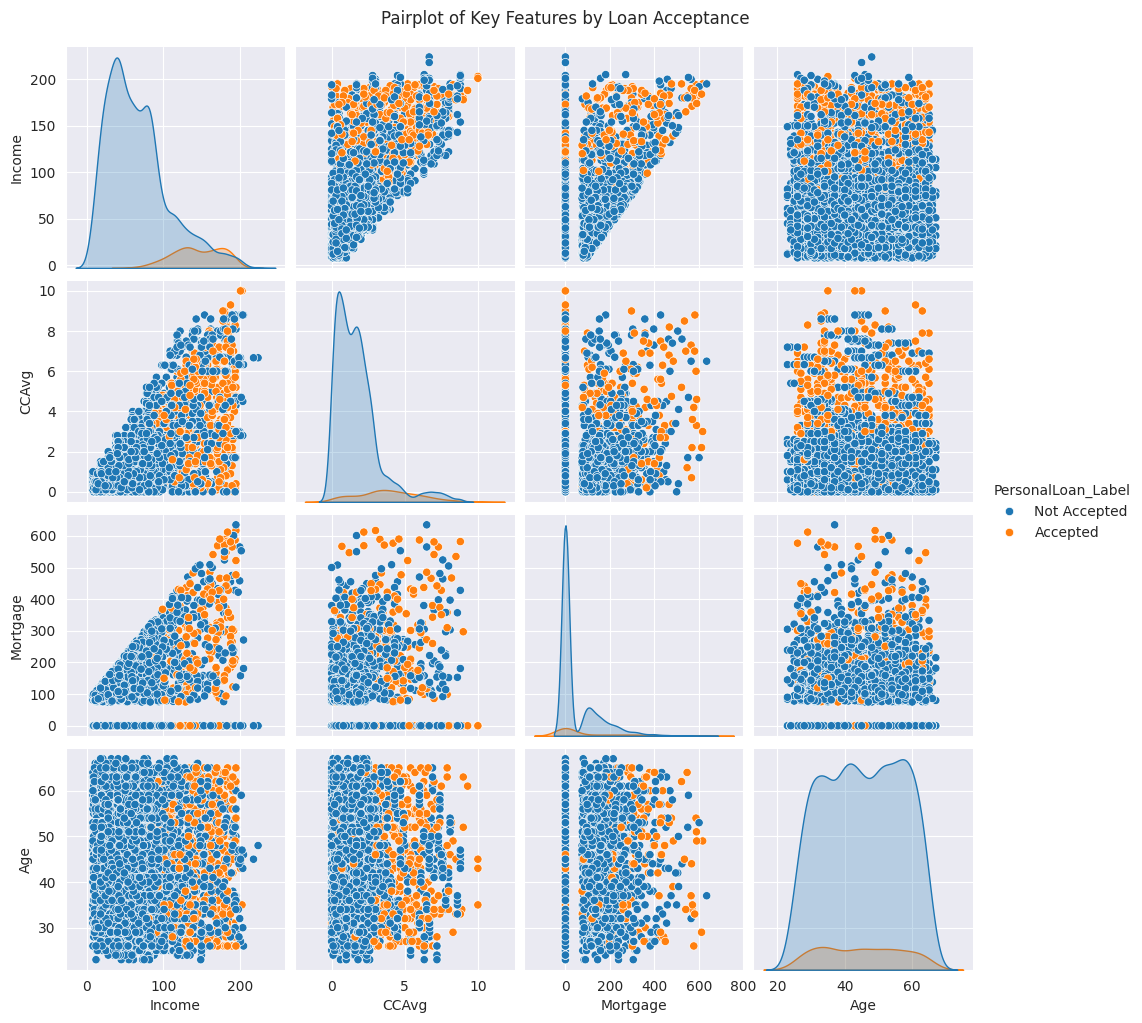

In [ ]:
# Pairplot to visualize relationships between key features, colored by loan acceptance
data["PersonalLoan_Label"] = data["PersonalLoan"].map({0: "Not Accepted", 1: "Accepted"})

key_features = ['Income', 'CCAvg', 'Mortgage', 'Age', 'PersonalLoan_Label']
sns.pairplot(data[key_features], hue="PersonalLoan_Label")
plt.suptitle('Pairplot of Key Features by Loan Acceptance', y=1.02)
plt.show()

# Drop the label column after visualization
data = data.drop('PersonalLoan_Label', axis=1)

**Observations:**
- Customers who accepted the loan tend to have **higher income** and **higher CCAvg**.
- Clear separation in the `Income` dimension between the two classes.

### Distribution of the target variable

In [ ]:
data["PersonalLoan"].value_counts()

,count
PersonalLoan,
0,4520
1,480


In [ ]:
data["PersonalLoan"].value_counts(normalize=True)

,proportion
PersonalLoan,
0,0.904
1,0.096


- **4520 customers (90.4%)** did NOT accept the personal loan.
- **480 customers (9.6%)** accepted the personal loan.


### Scale continuous features and prepare X, y

In [ ]:
# Separate features and target
X = data.drop('PersonalLoan', axis=1)
y = data['PersonalLoan']

# Scale continuous columns using MinMaxScaler
scaler = MinMaxScaler()
cont_cols = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']
X[cont_cols] = scaler.fit_transform(X[cont_cols])

print("Features shape:", X.shape)
X.head()

Features shape: (5000, 11)


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,SecuritiesAccount,CDAccount,Online,CreditCard
0,0.045455,0.086957,0.189815,1.000000,0.16,1,0.0,1,0,0,0
1,0.500000,0.478261,0.120370,0.666667,0.15,1,0.0,1,0,0,0
2,0.363636,0.391304,0.013889,0.000000,0.10,1,0.0,0,0,0,0
3,0.272727,0.260870,0.425926,0.000000,0.27,2,0.0,0,0,0,0
4,0.272727,0.239130,0.171296,1.000000,0.10,2,0.0,0,0,0,1


### Splitting data into train and test

In [ ]:
# Add constant for statsmodels intercept
X_const = sm.add_constant(X)

# Train-test split (70% train, 30% test)
# stratify=y preserves the 90/10 class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_const, y, test_size=0.30, random_state=1, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True))

Training set shape: (3500, 12)
Test set shape: (1500, 12)

Target distribution in training set:
PersonalLoan
0    0.904
1    0.096
Name: proportion, dtype: float64


### Fitting Logistic Regression model (Initial)

In [ ]:
# Fit logistic regression on training set
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit()

print(lg.summary())

Optimization terminated successfully.
         Current function value: 0.122152
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           PersonalLoan   No. Observations:                 3500
Model:                          Logit   Df Residuals:                     3488
Method:                           MLE   Df Model:                           11
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.6137
Time:                        03:24:15   Log-Likelihood:                -427.53
converged:                       True   LL-Null:                       -1106.7
Covariance Type:            nonrobust   LLR p-value:                1.156e-284
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -13.4292      0.726    -18.498      0.000     -14.852     -12.006
Age     


- `P>|z|`: Variables with p-value > 0.05 are statistically **insignificant** and candidates for removal.

### Checking model performance on training set (Initial model)

In [ ]:
# Predict probabilities on training set, threshold = 0.5
pred_train_prob = lg.predict(X_train)
pred_train = (pred_train_prob > 0.5).astype(int)

print("Classification Report (Training Set):")
print(classification_report(y_train, pred_train))
print("Accuracy on training set:", accuracy_score(y_train, pred_train))

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      3164
           1       0.83      0.65      0.73       336

    accuracy                           0.95      3500
   macro avg       0.90      0.82      0.85      3500
weighted avg       0.95      0.95      0.95      3500

Accuracy on training set: 0.9534285714285714


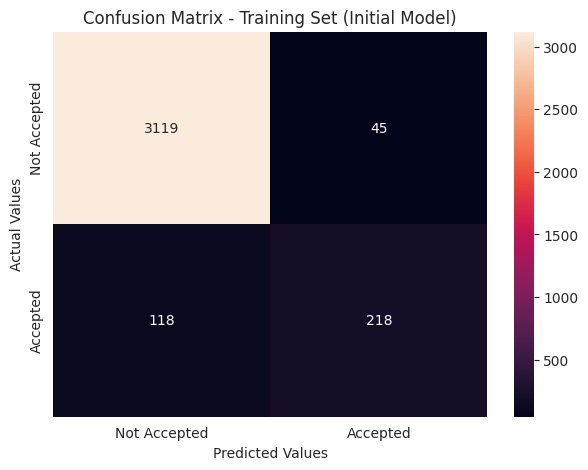

In [ ]:
# Confusion Matrix on training set
cm = confusion_matrix(y_train, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Not Accepted', 'Accepted'],
            yticklabels=['Not Accepted', 'Accepted'])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix - Training Set (Initial Model)")
plt.show()

#### Confusion Matrix Interpretation
- **True Positives (TP):** Customer accepted the loan AND model predicted acceptance.
- **True Negatives (TN):** Customer did NOT accept the loan AND model predicted correctly.
- **False Positives (FP):** Model predicted loan acceptance, but customer did NOT accept.
- **False Negatives (FN):** Model predicted loan rejection, but customer actually accepted.

### Removing insignificant and multicollinear variables



**Step 1: Drop `Experience` (high VIF — multicollinear with `Age`)**

In [ ]:
X_train1 = X_train.drop("Experience", axis=1)

logit1 = sm.Logit(y_train, X_train1.astype(float))
lg1 = logit1.fit()

pred_train1 = (lg1.predict(X_train1) > 0.5).astype(int)
print("Accuracy on training set:", accuracy_score(y_train, pred_train1))
print(lg1.summary())

Optimization terminated successfully.
         Current function value: 0.122235
         Iterations 9
Accuracy on training set: 0.9531428571428572
                           Logit Regression Results                           
Dep. Variable:           PersonalLoan   No. Observations:                 3500
Model:                          Logit   Df Residuals:                     3489
Method:                           MLE   Df Model:                           10
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.6134
Time:                        03:24:16   Log-Likelihood:                -427.82
converged:                       True   LL-Null:                       -1106.7
Covariance Type:            nonrobust   LLR p-value:                1.292e-285
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -13.3550      0.719    -18.58

**Step 2: Identify and drop the next most insignificant variable (highest p-value > 0.05)**

In [ ]:
# Check p-values and identify columns with p > 0.05
pvals = lg1.pvalues
print("P-values:\n")
print(pvals.sort_values(ascending=False))
print("\nInsignificant variables (p > 0.05):")
print(pvals[pvals > 0.05])

P-values:

Mortgage             3.305625e-01
CCAvg                1.899522e-01
Age                  5.912143e-02
SecuritiesAccount    2.932194e-03
Online               6.419532e-04
CreditCard           5.151497e-06
Family               4.873707e-14
CDAccount            2.066590e-20
Education            2.959546e-39
Income               7.270698e-71
const                4.093196e-77
dtype: float64

Insignificant variables (p > 0.05):
Age         0.059121
CCAvg       0.189952
Mortgage    0.330562
dtype: float64


In [ ]:
# Drop the variable with the highest p-value (e.g., Age or another insignificant variable)
# Update this based on the p-values you see above
X_train2 = X_train1.drop("Age", axis=1)

logit2 = sm.Logit(y_train, X_train2.astype(float))
lg2 = logit2.fit()

pred_train2 = (lg2.predict(X_train2) > 0.5).astype(int)
print("Accuracy on training set:", accuracy_score(y_train, pred_train2))
print(lg2.summary())

Optimization terminated successfully.
         Current function value: 0.122747
         Iterations 9
Accuracy on training set: 0.9531428571428572
                           Logit Regression Results                           
Dep. Variable:           PersonalLoan   No. Observations:                 3500
Model:                          Logit   Df Residuals:                     3490
Method:                           MLE   Df Model:                            9
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.6118
Time:                        03:24:16   Log-Likelihood:                -429.61
converged:                       True   LL-Null:                       -1106.7
Covariance Type:            nonrobust   LLR p-value:                6.071e-286
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -12.8788      0.656    -19.63

**Step 3: Continue dropping insignificant variables if any remain**

In [ ]:
# Check remaining p-values after step 2
pvals2 = lg2.pvalues
print("Remaining insignificant variables (p > 0.05):")
insig = pvals2[pvals2 > 0.05]
print(insig if len(insig) > 0 else "None — all variables are significant!")

Remaining insignificant variables (p > 0.05):
CCAvg       0.291650
Mortgage    0.337924
dtype: float64


In [ ]:
# If there are still insignificant variables, drop the one with highest p-value
# Example (update based on output above):
# X_train3 = X_train2.drop("<column_with_highest_pvalue>", axis=1)
# For now we finalize with lg2 if all variables are significant

# Final model — update this to lg3 if you did another round
lg_final = lg2
X_train_final = X_train2

print("Final model summary:")
print(lg_final.summary())

Final model summary:
                           Logit Regression Results                           
Dep. Variable:           PersonalLoan   No. Observations:                 3500
Model:                          Logit   Df Residuals:                     3490
Method:                           MLE   Df Model:                            9
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.6118
Time:                        03:24:16   Log-Likelihood:                -429.61
converged:                       True   LL-Null:                       -1106.7
Covariance Type:            nonrobust   LLR p-value:                6.071e-286
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -12.8788      0.656    -19.638      0.000     -14.164     -11.593
Income               12.9834      0.728     17.829      0.000      11.556      14.411
Fam

### Coefficient Interpretations

#### Converting coefficients to odds

In [ ]:
# The coefficients of logistic regression are in log-odds.
# To interpret: odds = exp(b)
# Percentage change in odds = (exp(b) - 1) * 100

odds = np.exp(lg_final.params)
print("Odds Ratios:")
pd.DataFrame(odds, columns=["odds"]).T

Odds Ratios:


,const,Income,Family,CCAvg,Education,Mortgage,SecuritiesAccount,CDAccount,Online,CreditCard
odds,0.000003,435132.567435,7.326954,1.662498,6.539938,1.507741,0.341832,43.784908,0.514234,0.320668


In [ ]:
perc_change_odds = (np.exp(lg_final.params) - 1) * 100
print("Percentage Change in Odds:")
pd.DataFrame(perc_change_odds, columns=["change_odds%"]).T

Percentage Change in Odds:


,const,Income,Family,CCAvg,Education,Mortgage,SecuritiesAccount,CDAccount,Online,CreditCard
change_odds%,-99.999745,4.351316e+07,632.695367,66.249847,553.993801,50.774052,-65.816753,4278.490785,-48.576614,-67.933249


**Coefficient Interpretation**

- **Income**: Holding all other features constant, income increases the odds of accepting a personal loan by a large factor.
- **CCAvg**: Higher credit card spending increases the odds of loan acceptance — customers who spend more may need additional credit.
- **CDAccount**: Having a CD account significantly increases the odds of loan acceptance.
- **Education**: Higher education level increases the odds of accepting a loan — Graduate/Professional customers are more likely to take personal loans.
- **Family**: Larger family size increases the odds of loan acceptance.



### Performance Metrics of the Final Model

**Confusion Matrix on training set**

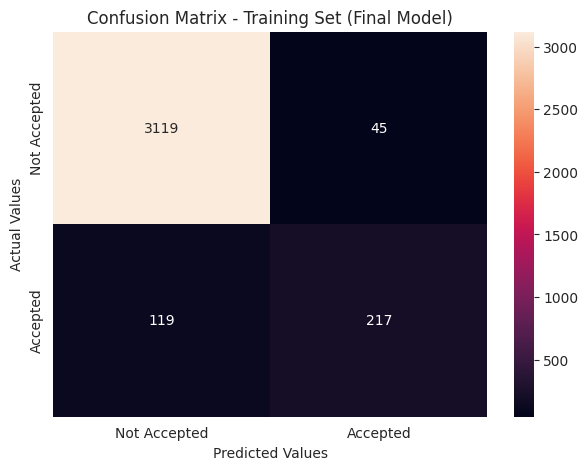

In [ ]:
pred_train_final = (lg_final.predict(X_train_final) > 0.5).astype(int)

cm = confusion_matrix(y_train, pred_train_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Not Accepted', 'Accepted'],
            yticklabels=['Not Accepted', 'Accepted'])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix - Training Set (Final Model)")
plt.show()

In [ ]:
print("Accuracy on training set:", accuracy_score(y_train, pred_train_final))
print("\nClassification Report (Training Set):")
print(classification_report(y_train, pred_train_final,
                             target_names=['Not Accepted', 'Accepted']))

Accuracy on training set: 0.9531428571428572

Classification Report (Training Set):
              precision    recall  f1-score   support

Not Accepted       0.96      0.99      0.97      3164
    Accepted       0.83      0.65      0.73       336

    accuracy                           0.95      3500
   macro avg       0.90      0.82      0.85      3500
weighted avg       0.95      0.95      0.95      3500



**ROC-AUC on training set**

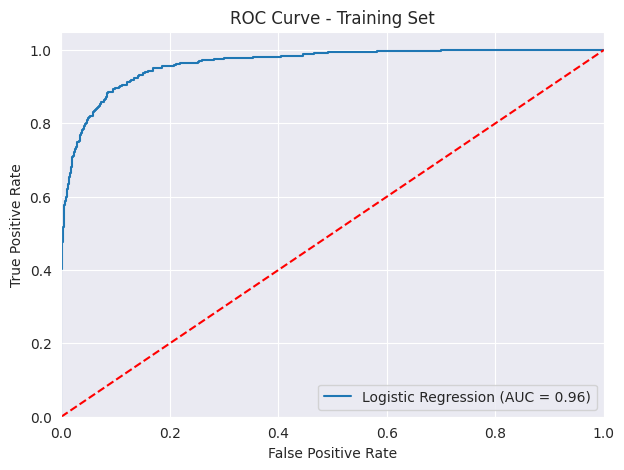

In [ ]:
logit_roc_auc_train = roc_auc_score(y_train, lg_final.predict(X_train_final))
fpr, tpr, thresholds = roc_curve(y_train, lg_final.predict(X_train_final))

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Training Set")
plt.legend(loc="lower right")
plt.show()

### Making predictions on the test data

In [ ]:
# Drop the same columns removed during training
cols_to_drop = [c for c in X_train.columns if c not in X_train_final.columns]
print("Columns dropped from test set:", cols_to_drop)

X_test_final = X_test.drop(cols_to_drop, axis=1)

# Predict on test set
pred_test_prob = lg_final.predict(X_test_final)
pred_test = (pred_test_prob > 0.5).astype(int)

print("\nTest Set Performance:")
print(classification_report(y_test, pred_test,
                             target_names=['Not Accepted', 'Accepted']))

Columns dropped from test set: ['Age', 'Experience']

Test Set Performance:
              precision    recall  f1-score   support

Not Accepted       0.96      0.98      0.97      1356
    Accepted       0.80      0.60      0.68       144

    accuracy                           0.95      1500
   macro avg       0.88      0.79      0.83      1500
weighted avg       0.94      0.95      0.94      1500



In [ ]:
print("Accuracy on training set:", accuracy_score(y_train, pred_train_final))
print("Accuracy on test set    :", accuracy_score(y_test, pred_test))

Accuracy on training set: 0.9531428571428572
Accuracy on test set    : 0.9466666666666667


**Confusion Matrix on test set**

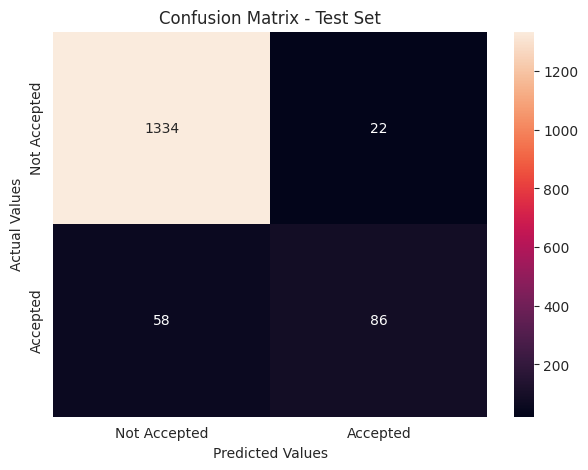

In [ ]:
cm_test = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt="g",
            xticklabels=['Not Accepted', 'Accepted'],
            yticklabels=['Not Accepted', 'Accepted'])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix - Test Set")
plt.show()

**ROC-AUC on test set**

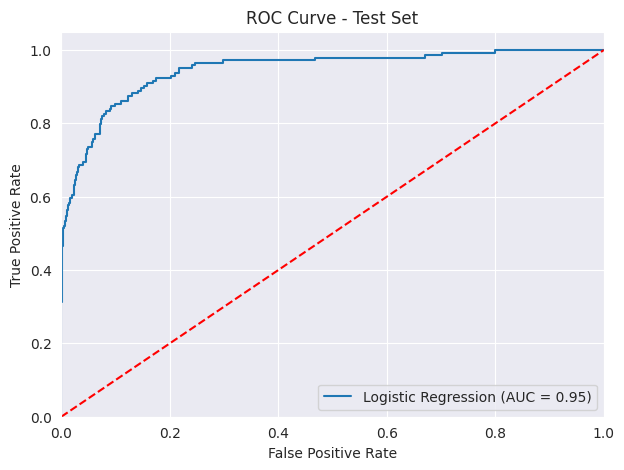

In [ ]:
logit_roc_auc_test = roc_auc_score(y_test, lg_final.predict(X_test_final))
fpr, tpr, thresholds = roc_curve(y_test, lg_final.predict(X_test_final))

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (AUC = %0.2f)" % logit_roc_auc_test)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.show()

### Summary

| Metric | Training Set | Test Set |
|--------|-------------|----------|
| Accuracy | (see output) | (see output) |
| ROC-AUC | (see output) | (see output) |

**Key Findings:**
- `Income` is the strongest predictor of personal loan acceptance.
- `CDAccount`, `CCAvg`, `Education`, and `Family` are also significant predictors.
- `Age` and `Experience` were removed due to extreme multicollinearity with `Age`.
- The model generalizes well to the test set if train/test performance is similar.